In [4]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from notebook_setup import *

# Data quality checking and Data cleaning

This file details the data quality of the "portefeuille" and "consommation" files and also the method chosen to clean the data in the portfolio file. 

This notebook can help to better understand the data cleaning conducted in the fonction *portfolio_cleaning* in the *data_processing* folder

##### Import standard libraries and loading the data

In [5]:
#Import libraries and modules
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.Visualisation import plot_hist_top_k
from src.utils.TransformData import make_binary_numeric, stacked_bar
from src.data_processing.data_load import data_loading

In [6]:
# Load data from training set
df_consommations, df_impayes, df_interactions, df_portefeuille, df_reclamations = data_loading("training")

c:\Users\kelly\BDC-Alptis\src\data_processing\data_load.py:19: DtypeWarning: Columns (0: client_nps_date_reponse_n_moins1, 1: client_nps_verbatim_n_moins1) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frames[key] = pd.read_csv(filepath, sep=";")


## Data quality overview

### Porfolio file analysis

In [7]:
# Size of data
df_portefeuille.info()

<class 'pandas.DataFrame'>
RangeIndex: 132576 entries, 0 to 132575
Data columns (total 47 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   client_code                                  132576 non-null  int64  
 1   client_age_souscripteur                      132576 non-null  int64  
 2   client_sexe_souscripteur                     132576 non-null  str    
 3   client_ro_souscripteur                       132576 non-null  str    
 4   client_code_postal                           132576 non-null  int64  
 5   client_departement                           132576 non-null  int64  
 6   client_departement_avant_changement_12_mois  465 non-null     float64
 7   client_a_conjoint                            132576 non-null  float64
 8   client_nb_enfants                            132576 non-null  float64
 9   client_structure_familiale                   132576 non-null  str    


In [8]:
# Décomposition categorical and numerical variables
categorical = df_portefeuille.select_dtypes(include=["object","bool"]).columns.to_list() 
numerical = df_portefeuille.select_dtypes(exclude=["object","bool"]).columns.to_list()
df_portefeuille_cat= df_portefeuille[categorical]
df_portefeuille_num = df_portefeuille[numerical]
df_portefeuille_num.describe().round(2)

C:\Users\kelly\AppData\Local\Temp\ipykernel_14696\1249500183.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df_portefeuille.select_dtypes(include=["object","bool"]).columns.to_list()


,client_code,client_age_souscripteur,client_code_postal,client_departement,client_departement_avant_changement_12_mois,client_a_conjoint,client_nb_enfants,client_nb_assures_contrat,client_a_garantie_prevoyance,client_est_contrat_madelin,...,courtier_code_partenaire,courtier_anciennete_annees,courtier_code_apporteur,courtier_code_avant_changement_12_mois,courtier_est_escompte,courtier_nb_affaires_n_moins1,courtier_nb_radiations_n_moins1,courtier_nb_affaires_n_moins2,courtier_nb_radiations_n_moins2,target_resiliation_6mois
count,132576.00,132576.00,132576.00,132576.00,465.00,132576.00,132576.00,132576.00,132576.00,132576.00,...,132576.00,132576.00,132576.00,7816.00,132576.00,132576.00,132576.00,132576.00,132576.00,132576.00
mean,13034003.65,63.40,56452.07,56.14,58.14,0.29,0.17,1.46,0.04,0.12,...,245778.17,11.35,386904.71,264203.76,0.26,473.19,285.13,354.98,304.18,0.11
std,3337758.76,16.47,28295.23,28.30,27.75,0.45,0.56,0.77,0.19,0.33,...,168562.73,8.17,149059.99,164884.96,0.44,965.69,569.76,749.22,635.07,0.31
min,21736.00,16.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,...,70099.00,0.00,5559.00,10032.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,11618361.25,54.00,33220.00,33.00,34.00,0.00,0.00,1.00,0.00,0.00,...,105281.00,5.00,214110.00,140239.00,0.00,2.00,1.00,0.00,0.00,0.00
50%,14413102.50,66.00,64600.00,64.00,69.00,0.00,0.00,1.00,0.00,0.00,...,128738.00,10.00,453650.00,140638.00,0.00,37.00,12.00,8.00,8.00,0.00
75%,15461161.75,75.00,76620.00,76.00,78.00,1.00,0.00,2.00,0.00,0.00,...,375040.00,16.00,493648.00,449506.00,1.00,404.00,166.00,145.00,119.00,0.00
max,16206912.00,107.00,98846.00,98.00,97.00,1.00,10.00,12.00,1.00,1.00,...,557376.00,123.00,632640.00,632220.00,1.00,3400.00,1908.00,2561.00,2141.00,1.00


In [9]:
# Tools for overview of categorical variables
dict_of_frequencies = {}
for c, var in enumerate(df_portefeuille_cat.columns):
    label = df_portefeuille_cat.columns[c]
    current_df_frequency = df_portefeuille_cat[var].value_counts(normalize=True).to_frame("frequency").reset_index(names=var)
    current_df_frequency["frequency"] = current_df_frequency["frequency"]*100
    dict_of_frequencies[label] = current_df_frequency
    current_df_frequency = None

**Conclusions**
- The portfolio file contains 47 variables about 132576 client. 
- Certains columns of the portfolio only concerns certains clients (client_departement_avant_changement_12_mois, courtier_code_avant_changement_12_mois) which explains why they contains a lot of Na values
- Certains columns contains missing values (courtier_type_commission and client_nom_banque)

### Secondary files

In [10]:
#Number of clients in secondary files (compared to portfolio)

dfs = {
    "Consommations": df_consommations,
    "Impayés": df_impayes,
    "Interactions": df_interactions,
    "Réclamations": df_reclamations
}

for nom, df in dfs.items():
    print(f"{nom} : {df["client_code"].nunique()} clients, {round(df['client_code'].nunique() / df_portefeuille["client_code"].nunique() * 100, 1)} % of total clients")


Consommations : 120907 clients, 91.2 % of total clients
Impayés : 7167 clients, 5.4 % of total clients
Interactions : 65895 clients, 49.7 % of total clients
Réclamations : 7393 clients, 5.6 % of total clients


**Conclusions** 

- The secondary files do not contain missing values, since new lines is created when a reclamation, interaction or a consumption is registered in Alptis system 

- The secondary files contains less clients than in the portfolio file:
  - The consommation file contains only 91.2% of the clients meaning that the 9% left have not recquired medical care in 2023. 
  - The impayés and réclamations files contains a minority of clients (around 5%) 
  - The interaction files only contains half of Alptis clients

Hence, the secondary files have to be manipulated carefuly, especially the reclamations, impayés and interactions files since they only concern a minority of clients. 

## Data cleaning

First, let's clean the porfolio file

In [11]:
#Creation of cleaned dataset
df_portefeuille_cleaned=df_portefeuille.copy()

###  Creation of boolean columns

In [12]:
#Identification of columns that can be made booleans
boolean = [
    c
    for (c, count) in 
    pd.concat([df_portefeuille_cat, df_portefeuille_num], axis=1).nunique().items()
    if count == 2
]
boolean

['client_sexe_souscripteur',
 'client_a_conjoint',
 'client_a_garantie_prevoyance',
 'client_est_contrat_madelin',
 'courtier_est_escompte',
 'target_resiliation_6mois']

In [14]:
#Transformation of columns identified as specific to some clients into booleans

df_portefeuille_cleaned["client_demenagement_dans_les_12_mois"] = df_portefeuille_cleaned["client_departement_avant_changement_12_mois"].notna().astype(int)
df_portefeuille_cleaned["courtier_changement_dans_les_12_mois"]=df_portefeuille_cleaned["courtier_code_avant_changement_12_mois"].notna().astype(int)

We've created the following booleans to simplify the future manipulation of the variables: 
- *client_male_souscripteur*: indicate whether or not the client is a male
- *client_demenagement_dans_les_12_mois*: indicate whether or not the client has moved into a new departement in 2023
- *client_demenagement_dans_les_12_mois*: indicate whether or not the client has changed of broker in 2023

### Filling the missing values

In [15]:
# Identification of columns with missing values

missing_counts = df_portefeuille.isna().sum()
missing_counts = missing_counts[missing_counts > 0]
missing_percent = (missing_counts / len(df_portefeuille)) * 100
for col in missing_counts.index:
    print(f"{col}: {missing_counts[col]} ({missing_percent[col]:.2f}%)")


client_departement_avant_changement_12_mois: 132111 (99.65%)
client_cotisations_annualisees_n_moins2: 60870 (45.91%)
client_cotisations_annualisees_n_moins1: 37707 (28.44%)
client_nom_banque: 3466 (2.61%)
client_nps_date_reponse_n: 125100 (94.36%)
client_nps_note_reco_n: 125100 (94.36%)
client_nps_verbatim_n: 126629 (95.51%)
client_nps_date_reponse_n_moins1: 127060 (95.84%)
client_nps_note_reco_n_moins1: 127060 (95.84%)
client_nps_verbatim_n_moins1: 128204 (96.70%)
courtier_code_avant_changement_12_mois: 124760 (94.10%)
courtier_type_commission: 34872 (26.30%)


### Handling Missing Values

* **`client_departement_avant_changement_12_mois`**, **`courtier_code_avant_changement_12_mois`**
  These variables were transformed into boolean columns, so the original versions can likely be removed.

* **`client_cotisations_annualisees_n_moins2` / `client_cotisations_annualisees_n_moins1`**
  Missing values correspond to clients who joined during the month or the previous month.
  These missing values cannot be meaningfully imputed: we'll simply filter for clients who were already present in earlier periods when using these fields.

* **`client_nps_...`**
  Indicates that the client has not answered the survey so no possibility of filling this column. 

* **`client_nom_banque`**
  This column does not appear essential for the prediction task, and missing values are limited (around 2%).
  If analyses are performed on this variable, rows with missing values can simply be dropped.
  *Note: Missing values mostly correspond to payments made by cheque (rather than direct debit), see the plots next in the notebook.*

* **`courtier_type_commission`**
  This variable may not be crucial for predicting cancellations, but it can be useful for business decision-making (e.g., identifying cancellations with high broker commission costs).
  To fill its missing values, we rely on the variable **`courtier_code_apporteur`**.


**Column courtier_type_commission**

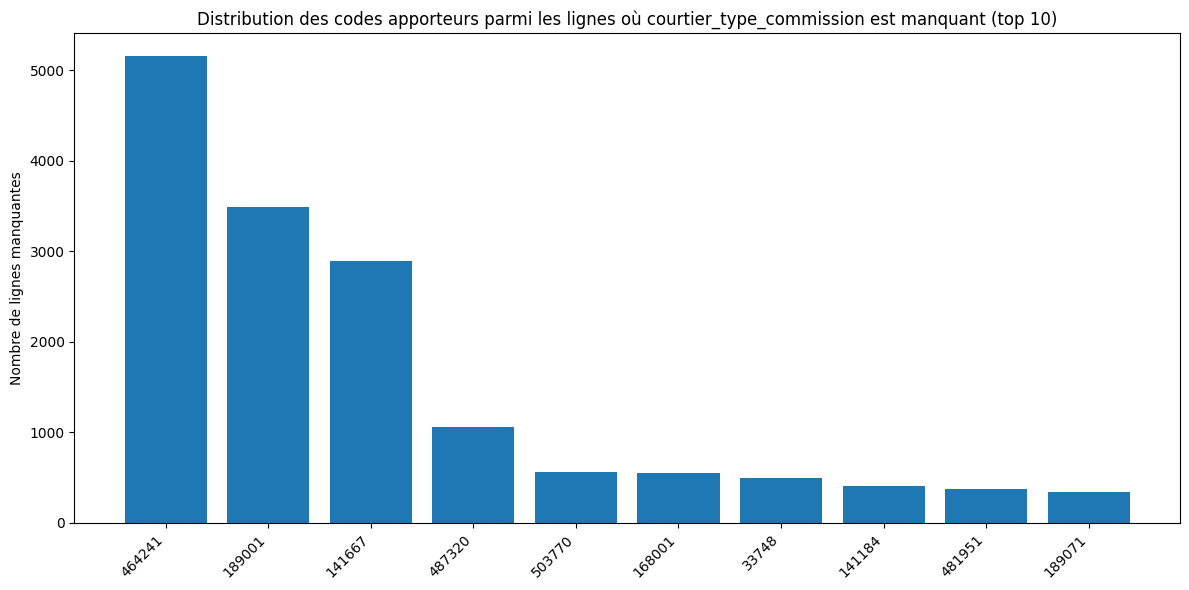

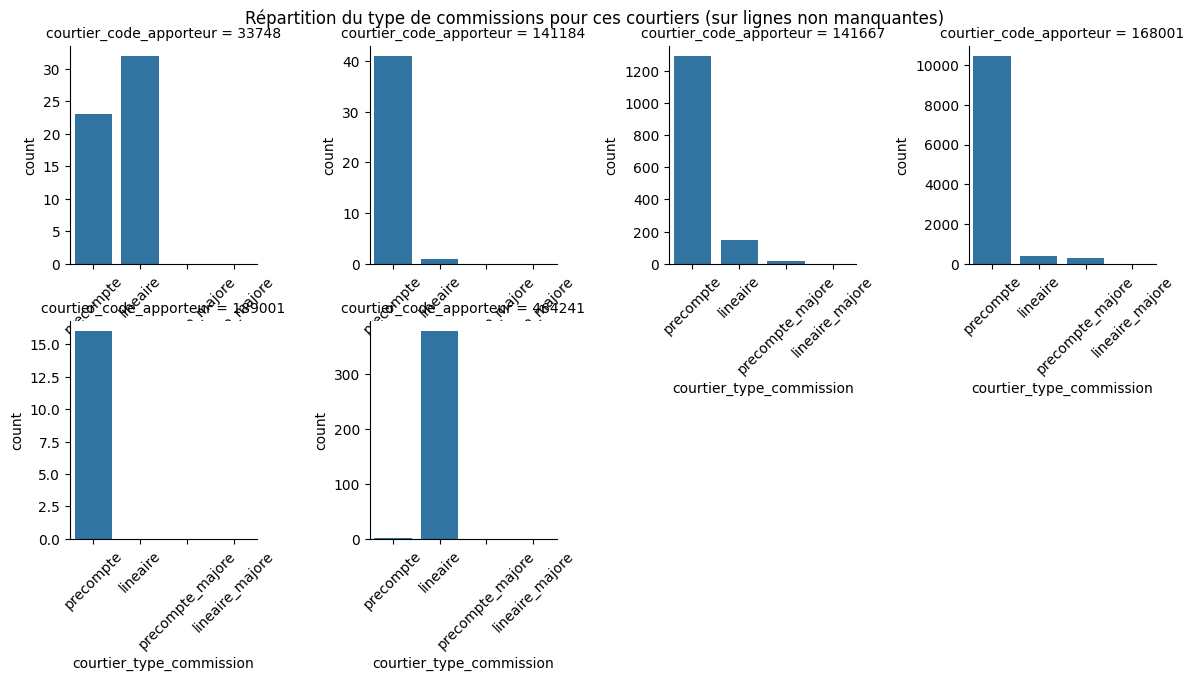

In [ ]:

#Répartition des codes apporteurs avec le plus de missing values sur courtier_type_commission
counts = (
    df_portefeuille[df_portefeuille["courtier_type_commission"].isna()]
    ["courtier_code_apporteur"]
    .value_counts()[0:10]
)

plt.figure(figsize=(12,6))
plt.bar(counts.index.astype(str), counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Nombre de lignes manquantes")
plt.title("Distribution des codes apporteurs parmi les lignes où courtier_type_commission est manquant (top 10)")
plt.tight_layout()
plt.show()

#Répartition du type de commissions de ces apporteurs, là où les lignes sont complétées
top_20_apporteur_missing_type_commission = (
    df_portefeuille[df_portefeuille["courtier_type_commission"].isna()][
        "courtier_code_apporteur"
    ].value_counts()[0:10]
)
apporteurs = top_20_apporteur_missing_type_commission.index
df_for_plots = df_portefeuille[
    df_portefeuille["courtier_code_apporteur"].isin(apporteurs)
    & df_portefeuille["courtier_type_commission"].notna()
]
g = sns.FacetGrid(
    df_for_plots,
    col="courtier_code_apporteur",
    col_wrap=4,          # 4 graphiques par ligne
    sharex=False,
    sharey=False,
    height=3
)
g.map(sns.countplot, "courtier_type_commission",
      order=df_for_plots["courtier_type_commission"].unique())

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel("count")
plt.subplots_adjust(top=0.92)
plt.suptitle("Répartition du type de commissions pour ces courtiers (sur lignes non manquantes)")
plt.show()

In [ ]:
#test de pureté pour prouver qu'un courtier est souvent associé à un type de commission
pureté = (
    df_portefeuille.groupby("courtier_code_apporteur")["courtier_type_commission"]
      .agg(lambda x: x.value_counts(normalize=True).max())
)
print(f"Pureté du type de commission par courtier: {pureté.mean().round(2)}")

Pureté du type de commission par courtier: 0.84


We can observe from these plots that most brokers who have missing values in the courtier_type_commission column tend to have one main type of commission across their clients. The purity test confirms this assumption with a score of 0.84.

Based on this pattern, we can use a simple imputation method: **for each missing value in courtier_type_commission, we fill it with the most frequent (dominant) commission type for that broker, using courtier_type_apporteur as the grouping reference.** In other words, if a broker typically has one type of commission, we assign that type to any missing entries for that broker. This approach leverages existing patterns in the data to fill missing values in a reasonable way.

In [ ]:
#Preuve de la fiabilité de la méthode

#On teste l'accuracy de notre méthode sur les données existantes:
#On prend les valeurs non manquantes et on masque aléatoirement 10% des lignes type de commission
df_test = df_portefeuille.copy()
connues = df_test["courtier_type_commission"].notna()
mask_test = connues & (np.random.rand(len(df_test)) < 0.1)
df_test.loc[mask_test, "courtier_type_commission"] = np.nan

# application de notre méthode d'imputation des données manquantes  
mode_par_courtier = (
    df_test.groupby("courtier_code_apporteur")["courtier_type_commission"]
           .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None) #type de commission la plus fréquente par type de courtier
)
df_test["courtier_type_commission"] = df_test["courtier_type_commission"].fillna(
    df_test["courtier_code_apporteur"].map(mode_par_courtier)
)

# on mesure l’exactitude de notre méthode
accuracy = (df_test.loc[mask_test, "courtier_type_commission"] == df_portefeuille.loc[mask_test, "courtier_type_commission"]).mean().round(3)
print("Accuracy =", accuracy)


Accuracy = 0.798


In [ ]:
#Mesure de l'accuracy ciblée sur les courtiers apporteurs qui ont des lignes  "types de commission" manquantes

df = df_portefeuille.copy()
#  Identifier les courtiers ayant des valeurs manquantes
courtiers_avec_na = df.loc[df["courtier_type_commission"].isna(), "courtier_code_apporteur"].unique()

#  Garder uniquement les lignes de ces courtiers avec VRAIES valeurs connues
df_cible = df[
    (df["courtier_code_apporteur"].isin(courtiers_avec_na)) &
    (df["courtier_type_commission"].notna())
].copy()


# On simule des données manquantes uniquement sur ces lignes-là
mask_test = np.random.rand(len(df_cible)) < 0.1
df_cible.loc[mask_test, "courtier_type_commission"] = np.nan


# Application de notre imputation
mode_par_courtier = (
    df_cible.groupby("courtier_code_apporteur")["courtier_type_commission"]
           .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

df_cible["courtier_type_commission"] = df_cible["courtier_type_commission"].fillna(
    df_cible["courtier_code_apporteur"].map(mode_par_courtier)
)

accuracy = (
    df_cible.loc[mask_test, "courtier_type_commission"]
    ==
    df.loc[df_cible.index].loc[mask_test, "courtier_type_commission"]
).mean().round(3)
print("Accuracy ciblée =", accuracy)


Accuracy ciblée = 0.808


The imputation method appears to be sufficiently reliable, achieving an accuracy of 0.79 when tested on masked data. The accuracy increases slightly to 0.80 when tested specifically on brokers who have missing values in their commission type. Let's apply it to the dataframe.

In [ ]:
#Imputing the missing values on courtier_type_commission using the method
mode_par_courtier = (
    df_portefeuille.groupby("courtier_code_apporteur")["courtier_type_commission"]
           .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

df_portefeuille_cleaned["courtier_type_commission"] = df_portefeuille["courtier_type_commission"].fillna(
    df_portefeuille["courtier_code_apporteur"].map(mode_par_courtier)
)

print(f"Number of filled missing values: {df_portefeuille["courtier_type_commission"].isna().sum()-df_portefeuille_cleaned["courtier_type_commission"].isna().sum()} \nNumber of remaning missing values after imputation: {df_portefeuille_cleaned["courtier_type_commission"].isna().sum()} \nPercentage of missing values after imputation: {round(df_portefeuille_cleaned["courtier_type_commission"].isna().sum()/df_portefeuille["client_code"].nunique()*100,2)} %")

Number of filled missing values: 30131 
Number of remaning missing values after imputation: 4741 
Percentage of missing values after imputation: 3.58 %


The method allowed to fill 30131 missing values bringing down the percentage of missing values on courtier_type_commission from 26% to 3.5%

**Column client_nom_banque**

A quick analysis of the column "client_mode_paiement" shows that most of the missing values on "client_nom_banque" concerns clients whose payments are made by cheque ('CHQ') and not directly debit ('PREL'). See the plots below.

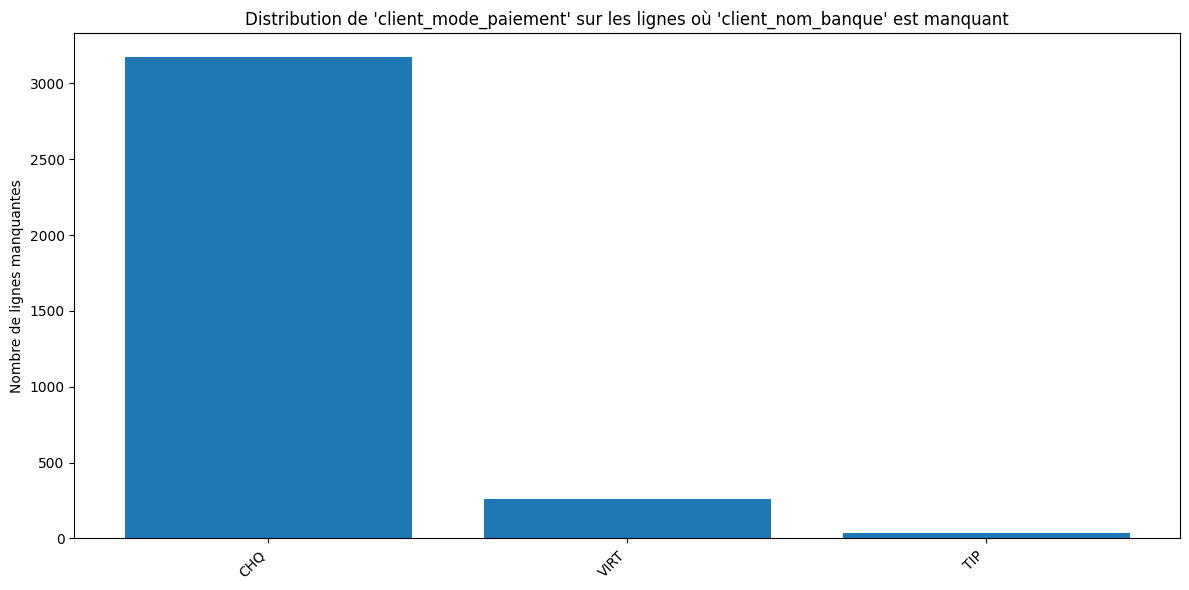

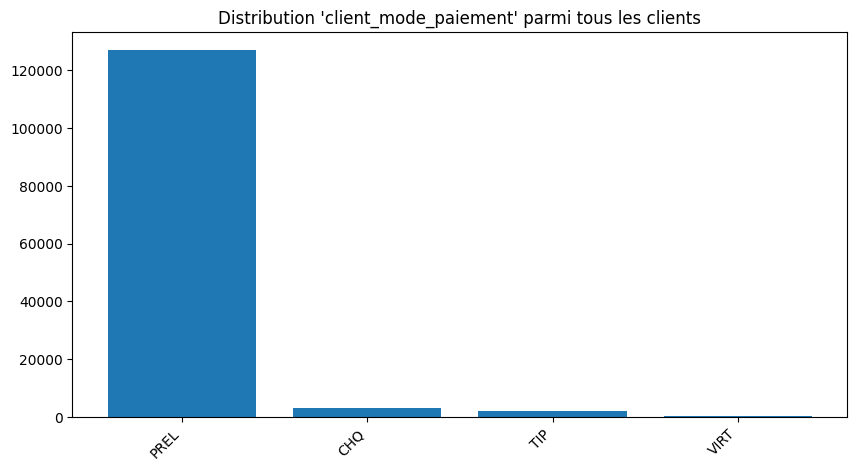

In [ ]:
#Type de paiement sur les lignes ou la banque n'est pas renseignée
counts=df_portefeuille[df_portefeuille["client_nom_banque"].isna()]["client_mode_paiement"].value_counts()
plt.figure(figsize=(12,6))
plt.bar(counts.index.astype(str), counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Nombre de lignes manquantes")
plt.title("Distribution de 'client_mode_paiement' sur les lignes où 'client_nom_banque' est manquant")
plt.tight_layout()
plt.show()

#Répartition type paiement chez tous les clients
counts = df_portefeuille["client_mode_paiement"].value_counts()
plt.figure(figsize=(10,5))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45, ha='right')
plt.title("Distribution 'client_mode_paiement' parmi tous les clients")
plt.show()

### Outliers detection

In [ ]:
df_portefeuille_client=df_portefeuille[[c for c in df_portefeuille.columns if c.startswith("client")]]
df_portefeuille_client.describe()

,client_code,client_age_souscripteur,client_code_postal,client_departement,client_departement_avant_changement_12_mois,client_a_conjoint,client_nb_enfants,client_nb_assures_contrat,client_a_garantie_prevoyance,client_est_contrat_madelin,client_anciennete_contrat_annees,client_cotisations_annualisees_n_moins2,client_cotisations_annualisees_n_moins1,client_cotisations_annualisees_n,client_cotisations_annualisees_n_plus1,client_nps_note_reco_n,client_nps_note_reco_n_moins1
count,1.325760e+05,132576.000000,132576.000000,132576.000000,465.000000,132576.000000,132576.000000,132576.000000,132576.000000,132576.000000,132576.000000,71706.000000,94869.000000,132576.000000,132576.000000,7476.000000,5516.000000
mean,1.303400e+07,63.395939,56452.065585,56.137589,58.139785,0.289871,0.167511,1.457383,0.039472,0.120459,4.911357,1537.025730,1517.991525,1547.638419,1756.765335,7.744783,7.624547
std,3.337759e+06,16.468106,28295.233389,28.304304,27.749026,0.453704,0.558127,0.767505,0.194715,0.325499,7.969260,1001.387873,961.241854,933.749550,1052.485225,2.339512,2.384425
min,2.173600e+04,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,138.000000,141.000000,138.000000,138.000000,0.000000,0.000000
25%,1.161836e+07,54.000000,33220.000000,33.000000,34.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,869.000000,878.000000,916.000000,1003.000000,7.000000,7.000000
50%,1.441310e+07,66.000000,64600.000000,64.000000,69.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,1271.000000,1269.000000,1316.000000,1499.000000,8.000000,8.000000
75%,1.546116e+07,75.000000,76620.000000,76.000000,78.000000,1.000000,0.000000,2.000000,0.000000,0.000000,6.000000,1925.000000,1908.000000,1955.000000,2236.000000,10.000000,10.000000
max,1.620691e+07,107.000000,98846.000000,98.000000,97.000000,1.000000,10.000000,12.000000,1.000000,1.000000,63.000000,15571.000000,16447.000000,17471.000000,19165.000000,10.000000,10.000000


In [ ]:
df_portefeuille_courtier=df_portefeuille[[c for c in df_portefeuille.columns if c.startswith("courtier")]]
df_portefeuille_courtier.describe()

,courtier_code_partenaire,courtier_anciennete_annees,courtier_code_apporteur,courtier_code_avant_changement_12_mois,courtier_est_escompte,courtier_nb_affaires_n_moins1,courtier_nb_radiations_n_moins1,courtier_nb_affaires_n_moins2,courtier_nb_radiations_n_moins2
count,132576.000000,132576.000000,132576.000000,7816.000000,132576.000000,132576.000000,132576.000000,132576.000000,132576.000000
mean,245778.170280,11.353314,386904.710445,264203.758956,0.264957,473.189107,285.132807,354.976504,304.181700
std,168562.734854,8.165189,149059.986332,164884.955943,0.441312,965.692391,569.761819,749.221780,635.069675
min,70099.000000,0.000000,5559.000000,10032.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,105281.000000,5.000000,214110.000000,140239.000000,0.000000,2.000000,1.000000,0.000000,0.000000
50%,128738.000000,10.000000,453650.000000,140638.000000,0.000000,37.000000,12.000000,8.000000,8.000000
75%,375040.000000,16.000000,493648.000000,449506.000000,1.000000,404.000000,166.000000,145.000000,119.000000
max,557376.000000,123.000000,632640.000000,632220.000000,1.000000,3400.000000,1908.000000,2561.000000,2141.000000


- Most of the values in the portfolio file seems correct at first sight
- We can only notice that some 'client_departement' are '00', which is abnormal. We replace these values by NaN

The secondary file do not recquired such a cleaning since they do not contain missing value. 
During our data exploration, we've identify some anomaly on column *reste_à_charge* from consommation file that worse the attention. **The costs for healthcare during January of 2023 has reached very high level, with a patient share of 76% which is suspicious.**

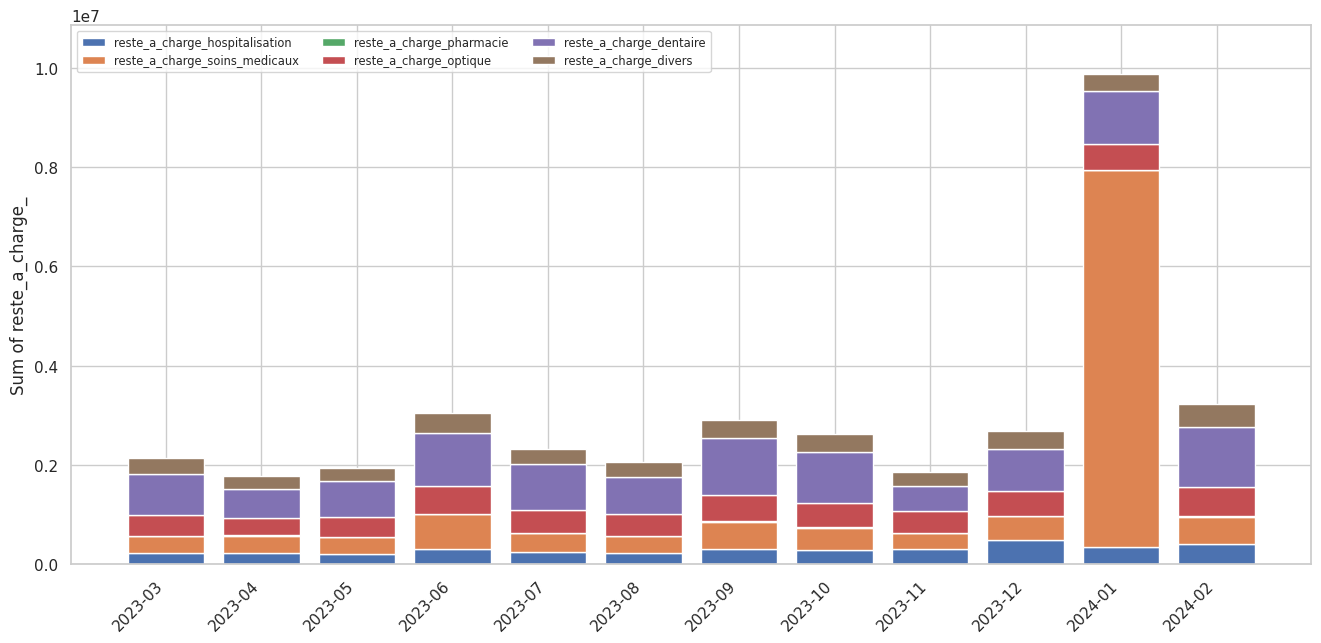

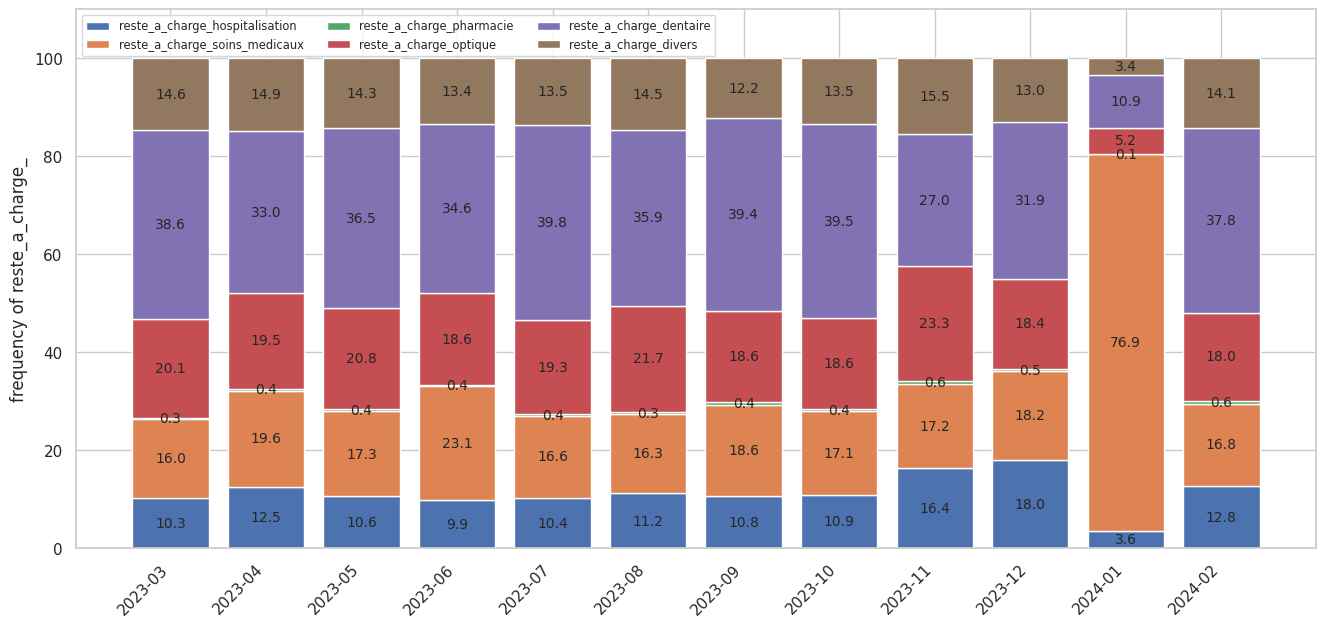

In [ ]:
# Aggregate the dataset by datetime
df_consommations['annee_mois_paiement'] = pd.to_datetime(df_consommations['annee_mois_paiement'], format='%Y-%m') + pd.offsets.MonthEnd(1)
list_numerical = df_consommations.select_dtypes(exclude=["object","bool", "datetime"]).columns.to_list()
list_datetime = df_consommations.select_dtypes(include=["datetime"]).columns.to_list()
df_conso_datetime = df_consommations[list_datetime + list_numerical].groupby(by='annee_mois_paiement').agg('sum').reset_index()
df_conso_datetime['month-year'] = df_conso_datetime['annee_mois_paiement'].dt.to_period('M').astype(str)
df_conso_datetime.head(5)

#Representing the distribution of costs among care types for each month of 2023
stacked_bar(data=df_conso_datetime, variable_root_name='reste_a_charge_', x_axis_variable='month-year', type_stack='classic')